# Model Training and Selection (Enhanced Data)

This notebook is part of the consolidated workflow. Do not change code logic; headings were added for structure.

## 1. Imports

Libraries required for model training and evaluation.


In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

## 2. Load Processed Data

Loading the enhanced processed datasets.


In [7]:
# Load processed data
train_df = pd.read_csv("../data/processed/train_enhanced_processed.csv")
test_df = pd.read_csv("../data/processed/test_enhanced_processed.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (12328, 296)
Test shape: (3083, 296)


## 3. Separate X and y

Prepare features and target for training.


In [8]:
# Separate features and target
X_train = train_df.drop(columns=['selling_price'])
y_train = train_df['selling_price']

X_test = test_df.drop(columns=['selling_price'])
y_test = test_df['selling_price']

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Training samples: {len(y_train)}")
print(f"Testing samples: {len(y_test)}")


Features: 295
Training samples: 12328
Testing samples: 3083


## 4. Define Models

Candidate models for training.


In [9]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    # 'Lasso': Lasso(alpha=0.001, max_iter=10000),
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_split=10,
        min_samples_leaf=4
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_split=10,
        min_samples_leaf=4
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        min_samples_split=10,
        min_samples_leaf=4
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        subsample=0.8,
        colsample_bytree=0.8
    )
}

## 5. Train and Evaluate

Train models and evaluate their performance on test data.


In [10]:
# Train and evaluate
results = []
trained_models = {}

print("\n" + "="*60)
print("TRAINING MODELS ON ENHANCED DATA")
print("="*60 + "\n")

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    train_time = time.time() - start_time
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Train Time (s)': train_time
    })
    
    trained_models[name] = model
    
    print(f"  ✓ MAE: ₹{mae:,.0f}")
    print(f"  ✓ R²:  {r2:.4f}")
    print(f"  ✓ Time: {train_time:.2f}s\n")



TRAINING MODELS ON ENHANCED DATA

Training Linear Regression...
  ✓ MAE: ₹176,690
  ✓ R²:  0.8125
  ✓ Time: 2.47s

Training Ridge...
  ✓ MAE: ₹179,919
  ✓ R²:  0.8129
  ✓ Time: 0.13s

Training Random Forest...
  ✓ MAE: ₹103,039
  ✓ R²:  0.9256
  ✓ Time: 12.98s

Training Extra Trees...
  ✓ MAE: ₹98,636
  ✓ R²:  0.9364
  ✓ Time: 17.07s

Training Gradient Boosting...
  ✓ MAE: ₹114,948
  ✓ R²:  0.8983
  ✓ Time: 46.98s

Training XGBoost...
  ✓ MAE: ₹97,149
  ✓ R²:  0.9459
  ✓ Time: 3.78s



In [11]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAE')

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df[['Model', 'MAE', 'RMSE', 'R2', 'Train Time (s)']].to_string(index=False))


MODEL PERFORMANCE COMPARISON
            Model           MAE          RMSE       R2  Train Time (s)
          XGBoost  97149.242188 201768.879107 0.945920        3.776245
      Extra Trees  98635.528480 218790.361829 0.936410       17.072746
    Random Forest 103039.160846 236624.684544 0.925621       12.980220
Gradient Boosting 114947.587037 276756.276717 0.898252       46.976156
Linear Regression 176690.487935 375646.546280 0.812548        2.470735
            Ridge 179919.296349 375322.678377 0.812871        0.133800


In [12]:
# Save results
results_df.to_csv('../reports/model_performance_enhanced.csv', index=False)

# Find the best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_r2 = results_df.iloc[0]['R2']
best_mae = results_df.iloc[0]['MAE']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   MAE: ₹{best_mae:,.0f}")
print(f"   R²:  {best_r2:.4f}")



🏆 BEST MODEL: XGBoost
   MAE: ₹97,149
   R²:  0.9459



✅ Best model saved: ../models/best_model_enhanced.pkl

TOP 20 IMPORTANT FEATURES
                               feature  importance
         num__engine_power_interaction    0.149816
                    cat__brand_Ferrari    0.135076
                  cat__model_GTC4Lusso    0.110474
                        num__max_power    0.081192
                      cat__model_Ghost    0.050153
                     cat__model_Innova    0.037851
               cat__brand_group_Luxury    0.027280
              cat__engine_category_Mid    0.025814
        cat__brand_model_Toyota_Innova    0.023558
                cat__brand_Rolls-Royce    0.023466
          cat__brand_group_Mass Market    0.021556
                           num__engine    0.017773
               num__age_km_interaction    0.016616
           cat__engine_category_Luxury    0.014678
                   cat__model_Wrangler    0.009179
                      num__vehicle_age    0.007790
cat__brand_model_Mercedes-Benz_E-Class    0.006488


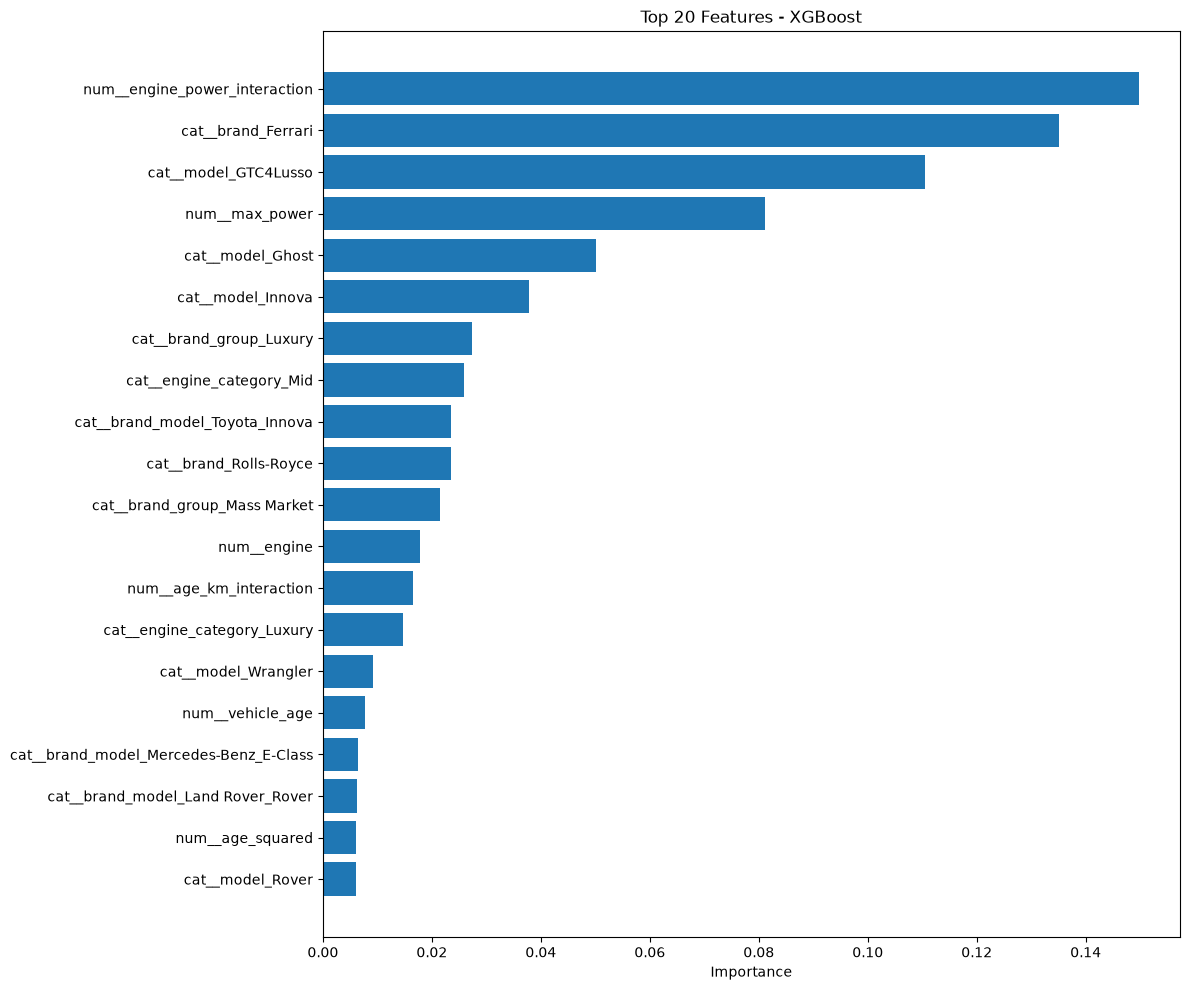

In [13]:
# Save best model
joblib.dump(best_model, '../models/best_model_enhanced.pkl')
print(f"\n✅ Best model saved: ../models/best_model_enhanced.pkl")

# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X_train.columns
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Show top 20 features
    print("\n" + "="*60)
    print("TOP 20 IMPORTANT FEATURES")
    print("="*60)
    print(importance_df.head(20).to_string(index=False))
    
    # Plot top 20 features
    plt.figure(figsize=(12, 10))
    top_features = importance_df.head(20)
    plt.barh(top_features['feature'], top_features['importance'])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    # plt.savefig('../reports/figures/feature_importance_enhanced.png', dpi=300, bbox_inches='tight')
    plt.show()